# **Lesson_9.1**

## In this lecture

* **CNN** for image classification task - **Part II**

*This lesson cover the first part of a sample course work focuced on **Image Classification** task using Convolutional Neural Network*
###### Based on "Predictive Analytics" module by the [Code Institute](https://codeinstitute.net/)

---

## Notebook objectives
* Build, train and test a convolutional neural network (CNN) for Classification task using an image dataset, assess the model performannce and run individual prediction on random image (from the test dataset)

## Inputs
Pre-processed dataset `../datasets/fashion_mnist_processed.npz`

## Outputs

## Notes and comments
*Jupyter Notebooks of lessons 8.2 and 9.1 cover sample .ipynb file of the "Image Classification" cource work. Please, bear in mind you will also have to submit README.md file, describing your ML pipeline (consult CW preparation guidelines)*

---

*... in the previous lecture*

### Import packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist  # Importing dataset
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

### Settings

In [3]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # tf will show error messages only (reduce verbosity)
sns.set_style('white')

---

### <u>Load data</u>

In [4]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
print(X_train.shape, X_test.shape)
# The dataset is already preprocessed and split into train and test

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (10000, 28, 28)


In [5]:
type(X_train)

numpy.ndarray

In [6]:
n_labels = len(np.unique(y_train))
n_labels

10

In [7]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

#### Workflow for data acquisition

* Load the data first. We are using the fashion_mnist dataset from tensorflow. It has 28x28 graiscale images of clothes and we are interested in predicting which piece of close it is.
* The data are split into train and test sets (It is available from TensorFlow in this format).
* This is a demo dataset, where all images are provided in a single and standardized format and arranged in a NumPy array.
* This is useful for learning purposes. However, actual image datasets rarely have the characteristic of having all images of the same size.

array pointer = 15
x_train[15] shape: (28, 28)
label: 9


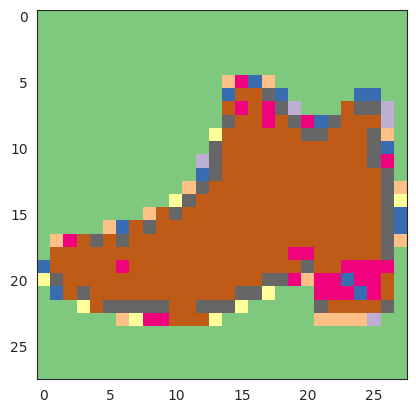

In [8]:
pointer = 15 # number of image in the dataset (remember, numbering starts from 0!)

print(f"array pointer = {pointer}")
print(f"x_train[{pointer}] shape: {X_train[pointer].shape}")
print(f"label: {y_train[pointer]}")

plt.imshow(X_train[pointer],cmap='Accent')
plt.show()

#### Fashion MNIST dataset labels

| Label | Clothing Item |
|------|---------------|
| 0 | T-shirt / Top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle Boot |

---

### <u>Data preparation</u>

Fashion MNIST dataset is already loaded as a NumPy array, there's no need to check file extensions like we **would do** for actual image files. However, we can still verify whether all elements in X_train, X_test, and Y_train are valid image data.

* Clean data.
    * Steps to Validate Images in Fashion MNIST
        * Check the data type → Images should be numeric arrays (uint8 type).
        * Check the shape of each image → All images should be 28×28 pixels.
        * Check for corrupted images (e.g., containing NaN values).

In [9]:
def check_images(dataset, dataset_name):
    """
    Checks images for:
    * being an array
    * shape (28x28)
    * colour channel values
    * NaN values
    """
    invalid_count = 0  # Counter for invalid images
    valid_count = 0     # Counter for valid images

    for idx, image in enumerate(dataset):
        # Check if the image is a NumPy array
        if not isinstance(image, np.ndarray):
            print(f"{dataset_name} - Index {idx}: Not a valid image array")
            invalid_count += 1
            continue

        # Check shape (should be 28x28)
        if image.shape != (28, 28):
            print(f"{dataset_name} - Index {idx}: Incorrect shape {image.shape}")
            invalid_count += 1
            continue

        # Check if values are within expected range (0-255 for grayscale images)
        if not (image.dtype == np.uint8 and image.min() >= 0 and image.max() <= 255):
            print(f"{dataset_name} - Index {idx}: Invalid pixel values (Min: {image.min()}, Max: {image.max()})")
            invalid_count += 1
            continue

        # Check for NaN values
        if np.isnan(image).any():
            print(f"{dataset_name} - Index {idx}: Contains NaN values")
            invalid_count += 1
            continue

        valid_count += 1

    print(f"\n{dataset_name}: {valid_count} valid images, {invalid_count} invalid images")


In [10]:
# Run checks on both datasets
print("Checking Images...\n")
check_images(X_train, "Train")
check_images(X_test, "Test")

Checking Images...


Train: 60000 valid images, 0 invalid images

Test: 10000 valid images, 0 invalid images


* Further data splitting: from the **train** set, we split a **validation** set. We set the validation set as 20% of the train set)

In [11]:
X_train, X_val, y_train, y_val = train_test_split(
                                    X_train,
                                    y_train,
                                    test_size=0.2,
                                    random_state=0
                                    )

print("* Train set:", X_train.shape, y_train.shape)
print("* Validation set:",  X_val.shape, y_val.shape)
print("* Test set:",   X_test.shape, y_test.shape)

* Train set: (48000, 28, 28) (48000,)
* Validation set: (12000, 28, 28) (12000,)
* Test set: (10000, 28, 28) (10000,)


---

### <u>EDA</u>

* Plot label frequency distribution in train, validation and test dataset

In [12]:
# Define class names. Fasion MNIST has 10 labels
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [13]:
# Create a DataFrame for label frequency distribution
df_freq = pd.DataFrame(columns=['Set', 'Label', 'Frequency'])


In [14]:
def count_labels(dataset, dataset_name):
    """
    Helper function to count occurrences of each label and print them
    """
    global df_freq
    unique, counts = np.unique(dataset, return_counts=True)  # Get label frequencies
    for label, frequency in zip(unique, counts):
        df_freq = pd.concat([df_freq, pd.DataFrame([{'Set': dataset_name, 'Label': class_names[label], 'Frequency': frequency}])], ignore_index=True)
        print(f"* {dataset_name} - {class_names[label]}: {frequency} images")  # Print formatted output

In [15]:
count_labels(y_train, "Train")
count_labels(y_test, "Test")
count_labels(y_val, "Validation")

* Train - T-shirt/top: 4816 images
* Train - Trouser: 4813 images
* Train - Pullover: 4794 images
* Train - Dress: 4775 images
* Train - Coat: 4783 images
* Train - Sandal: 4780 images
* Train - Shirt: 4814 images
* Train - Sneaker: 4844 images
* Train - Bag: 4792 images
* Train - Ankle boot: 4789 images
* Test - T-shirt/top: 1000 images
* Test - Trouser: 1000 images
* Test - Pullover: 1000 images
* Test - Dress: 1000 images
* Test - Coat: 1000 images
* Test - Sandal: 1000 images
* Test - Shirt: 1000 images
* Test - Sneaker: 1000 images
* Test - Bag: 1000 images
* Test - Ankle boot: 1000 images
* Validation - T-shirt/top: 1184 images
* Validation - Trouser: 1187 images
* Validation - Pullover: 1206 images
* Validation - Dress: 1225 images
* Validation - Coat: 1217 images
* Validation - Sandal: 1220 images
* Validation - Shirt: 1186 images
* Validation - Sneaker: 1156 images
* Validation - Bag: 1208 images
* Validation - Ankle boot: 1211 images


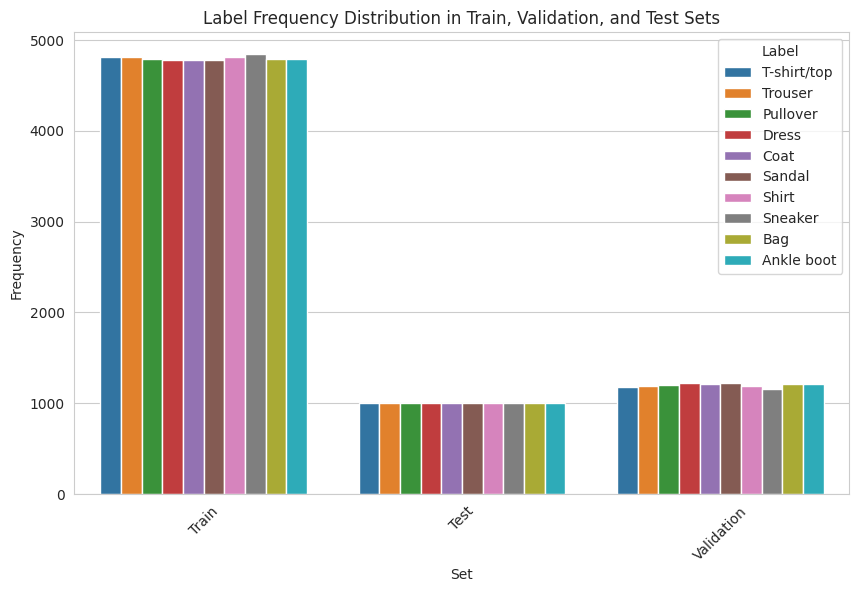

In [16]:
# Visualize the label distribution and save image
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=df_freq, x='Set', y='Frequency', hue='Label')
plt.xticks(rotation=45)
plt.title("Label Frequency Distribution in Train, Validation, and Test Sets")
# plt.savefig("/workspaces/m32895-coursework-2025/outputs/label_distribution_in_sets.png", bbox_inches='tight', dpi=150)
plt.show()

At this point we can ask ourselves:
* Is the dataset <u>balanced</u>?
* Do we have enough data?
* Are we going to run **augmentation**?


#### * We need to **reshape** and **rescale** the data to make it digestible by Tensorflow

In [17]:
# Current data shape:
X_train.shape

(48000, 28, 28)

* When using Convolutional Neural Networks (CNNs), the Fashion MNIST dataset needs to be reshaped to include a "channel" dimension because CNNs typically expect 4D input

| Dataset Type | Required Shape for CNN |
|--------------|------------------------|
| Grayscale Images (e.g. Fashion MNIST) | (num_images, height, width, 1) |
| RGB Images | (num_images, height, width, 3) |

N.b.: we are taking these steps for scaling the data and reshaping to include the channel dimension since the data was provided in such format and is in a NumPy array format

When you get image datasets in a NumPy format, you will recheck these items, and if required, you will need to process them.
However, when dealing with real images, the preprocessing tasks are done in another way, which we will cover in the walkthrough of project 1

In [18]:
# Reshape Fashion MNIST data for CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

# Check the new shape
print(X_train.shape)  # Expected output: (48000, 28, 28, 1)


(48000, 28, 28, 1)


* Convert to **float** and reshape.

In [19]:
X_train.max()

np.uint8(255)

In [20]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [21]:
X_train.max()

np.float32(1.0)

* What Happens After Scaling?

| Before Scaling (uint8) | After Scaling (float32) |
|---|---|
| Pixel values: 0 - 255 | Pixel values: 0.0 - 1.0 |
| Integer type (uint8) | Floating-point (float32)|
| Can cause instability in training | Helps stable and faster training |
* The model learns better and converges faster when inputs are scaled to [0,1].



In [22]:
# **Convert labels to categorical format**
n_labels = 10  # Fashion MNIST has 10 classes
y_train = to_categorical(y_train, num_classes=n_labels)
y_val = to_categorical(y_val, num_classes=n_labels)
y_test = to_categorical(y_test, num_classes=n_labels)

In [23]:
y_test

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 10))

*end of the previous lesson*

---
---

### Load dataset

In [24]:
# Load dataset pre-processed and saved in the previous Notebook
data = np.load("../datasets/fashion_mnist_processed.npz")

X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

FileNotFoundError: [Errno 2] No such file or directory: '../datasets/fashion_mnist_processed.npz'

In [25]:
print(X_train.shape, X_train.dtype)
print(y_train.shape, y_train.dtype)

(48000, 28, 28, 1) float32
(48000, 10) float64


### <u>Building our model</u>

* Finally! We are about to create a TensorFlow model

* We create a function that
    * creates a sequential model
    * compiles the model
    * returns the model
    
* The function needs the input shape (image size) as well as the number of neurons in the last layer
* The network has two pairs of Convolution + Pooling layers. It is know upfront that for this dataset that one pair would be enough; however, we want to try in this work different combination of layers and their parameters for educational purposes.
* <u>Brief summary</u> (refer to previous tutorials for more details):
    * **Convolution layers** are used to select the dominant pixel value from within images using filters
    * **Pooling layers** reduce the image size by extracting only the dominant pixels
* The first pair has a convolution layer with 16 filters and a kernel size of 3x3.
* We parse the input shape as well as the **relu** as an activation function.
* The **MaxPool** has a pool size of 2x2
* The next pair has the same setup as the previous pair
* Next, there is a Flatten layer
    * The Flatten layer is used to flatten the matrix into a vector, which means a single list of all values. Then that is fed into a dense layer.
* Next, there is a Dense layer with 128 neurons.


* Typically, here, you arrange the dense layers in multiples of 2, and the number of layers depends on the data complexity after the Flatten layer.
* We will check in the `.summary()` or `.plot_model()` that the data shape after the Flatten layer is 400, so it makes sense to reduce the number of neurons from this case, 400 to 128. So naturally, you will only know the output from the Flatten layer is 400 after creating a model and checking the summary/plot_model.
If the output from the Flatten layer were much higher, like 5k, you would consider two or more dense layers to reduce the number of connections progressively.
* The value 128 is a good starting point. If you notice the CNN is not learning, you may add more dense layers and adjust the number of neurons in them
* After, we have a dropout layer with a rate of 25% to reduce the chance of overfitting.
* **The output layer should reflect a multiclass classification.**
* We set a dense layer where the number of neurons equals the number of classes in the target variable. This information is stored in a previously created variable - `n_labels`.
* For multiclass classification, we set the activation function as softmax, and we compile the model with adam as the optimizer and the loss function as categorical_crossentropy.
* We also arranged to monitor the metric accuracy.

In [26]:
def build_tf_model(input_shape, n_labels):
  model = Sequential()

  model.add(Conv2D(filters=16, kernel_size=(3,3),input_shape=input_shape, activation='relu',))
  model.add(MaxPool2D(pool_size=(2, 2)))

  model.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu',))
  model.add(MaxPool2D(pool_size=(2, 2)))

  model.add(Flatten())

  model.add(Dense(128, activation='relu'))
  model.add(Dropout(0.25))

  model.add(Dense(n_labels, activation='softmax'))
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

  return model

In [27]:
n_labels = 10
model = build_tf_model(input_shape=X_train.shape[1:], n_labels=n_labels )
model.summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1774276289.540249    8056 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        51,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,098 (215.23 KB)

 Trainable params: 55,098 (215.23 KB)

 Non-trainable params: 0 (0.00 B)

---

### <u>Fit the model</u>

* Early stopping allows us to stop the training when a monitored metric has stopped improving
    * This is useful to avoid **overfitting** the model to the data.

* We will monitor the validation accuracy now
    * We set patience as 1, the number of epochs with no improvement, after which training will be stopped
    * There is no fixed rule to set patience
    * If you feel that your model is learning still and you stopped, you may increase the value and train again
    * However, we want the training process to be quick, (for demo purpose, n/a in your course work)
    * We set the mode to min since now we want the model to stop training when the loss didn't improve its performance and improve means decrease
* We will finally fit the model
    * We create the model object and use `.fit()`
    * We parse the Train set
    * The epochs are set to 4. We know in advance that this amount is fine to learn the patterns considering the dataset and the network structure
    * We parse the validation data in a tuple
    * Verbose is set to 1, so we can see in which epochs we are and the training and validation loss
    * Finally, we parse our callback as the early_stop object we created earlier
* For each epoch, note the training and validation loss and accuracy. Is it increasing? Decreasing? Static?
* Ideally, the loss should decrease as long as the epoch increases, showing a practical sign the network is learning. The accuracy should increase over the epochs.
* Note the model will take a bit longer now to train

In [98]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=1)

In [99]:
model = build_tf_model(input_shape= X_train.shape[1:], n_labels=n_labels )

model.fit(x=X_train,
          y=y_train,
          epochs=15,
          validation_data=(X_val, y_val),
          verbose=1,
          callbacks=[early_stop]
          )

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7860 - loss: 0.5833 - val_accuracy: 0.8377 - val_loss: 0.4338
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8531 - loss: 0.3992 - val_accuracy: 0.8686 - val_loss: 0.3659
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8731 - loss: 0.3471 - val_accuracy: 0.8785 - val_loss: 0.3324
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8839 - loss: 0.3164 - val_accuracy: 0.8863 - val_loss: 0.3191
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8927 - loss: 0.2935 - val_accuracy: 0.8905 - val_loss: 0.2932
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8979 - loss: 0.2771 - val_accuracy: 0.8932 - val_loss: 0.2856
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9035 - loss: 0.2617 - val_accuracy: 0.8963 - val_loss: 0.2813
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9075 - loss: 0

KeyboardInterrupt: 

---

### <u>Model evaluation</u>

* Evaluate the model performance by analysing the training and the validation losses and accuracy that happened during the training process
* In deep learning, we use the model history to assess if the model learned, using the train and validation sets
* We also evaluate separately how the model **generalises** on unseen data (on the test set)
* The model training history information is stored in a .history.history attribute from the model
* Note it shows loss and accuracy for train and validation

In [94]:
history = pd.DataFrame(model.history.history)
history.head(15)

,accuracy,loss,val_accuracy,val_loss
0,0.776167,0.608370,0.832167,0.434146
1,0.850875,0.405938,0.865083,0.360976
2,0.868792,0.357500,0.881333,0.326396
3,0.879062,0.330420,0.886500,0.305382
4,0.887333,0.306247,0.890333,0.298958
5,0.892958,0.288637,0.892250,0.297722
6,0.898979,0.273998,0.894833,0.283748
7,0.903042,0.260552,0.896083,0.277720
8,0.907062,0.248759,0.900000,0.274972
9,0.909021,0.241828,0.901750,0.272493


#### Plot accuracy and loss

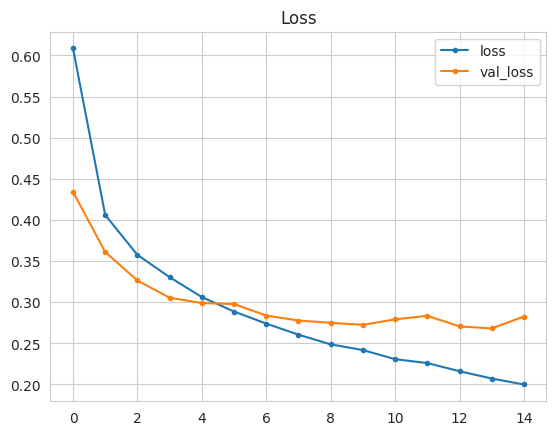

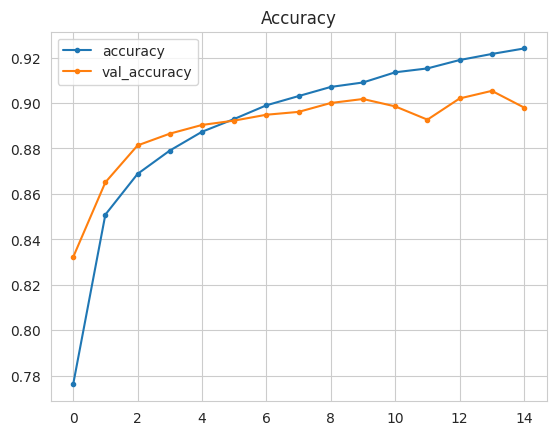

In [95]:
sns.set_style("whitegrid")
history[['loss','val_loss']].plot(style='.-')
plt.title("Loss")
plt.show()

print("\n")
history[['accuracy','val_accuracy']].plot(style='.-')
plt.title("Accuracy")
plt.show()

* We will evaluate the model performance on the test set, using `.evaluate()` and parsing the test set
* N.b. the value is not much different from the losses and accuracy in the train and validation set
* N.b. the loss is low and accuracy is high. It looks like the model has learned the relationships between the features and the target.

In [96]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8964 - loss: 0.2934


[0.2934105098247528, 0.896399974822998]

* In classification, you would analyse the confusion matrix and classification report using the custom function we have seen over the course.

In [97]:
def confusion_matrix_and_report(X, y, pipeline, label_map):
    """
    Print confusion matrix and report, and plot heatmap
    """

    # Predictions (convert from one-hot)
    prediction = pipeline.predict(X)
    prediction = np.argmax(prediction, axis=1)

    # True labels (convert from one-hot)
    y = np.argmax(y, axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(y_true=y, y_pred=prediction)

    print('---  Confusion Matrix  ---')
    print(pd.DataFrame(
        cm,
        columns=["Actual " + sub for sub in label_map],
        index=["Predicted " + sub for sub in label_map]
    ))
    print("\n")

    print('---  Classification Report  ---')
    print(classification_report(y, prediction, target_names=label_map), "\n")

    # 🔹 Plot heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_map,
        yticklabels=label_map
    )

    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

In [73]:
def clf_performance(X_train,y_train,X_test,y_test,X_val, y_val,pipeline,label_map):
  """
  Print classification performance
  """
  print("#### Train Set #### \n")
  confusion_matrix_and_report(X_train,y_train,pipeline,label_map)

  print("#### Validation Set #### \n")
  confusion_matrix_and_report(X_val,y_val,pipeline,label_map)

  print("#### Test Set ####\n")
  confusion_matrix_and_report(X_test,y_test,pipeline,label_map)

#### Train Set #### 

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
---  Confusion Matrix  ---
                       Actual T-shirt/top  Actual Trouser  Actual Pullover  \
Predicted T-shirt/top                4254               3               44   
Predicted Trouser                       0            4778                0   
Predicted Pullover                     46               3             4037   
Predicted Dress                        44               3               13   
Predicted Coat                          3               3               66   
Predicted Sandal                        0               0                0   
Predicted Shirt                       341               2              166   
Predicted Sneaker                       0               0                0   
Predicted Bag                           3               1                3   
Predicted Ankle boot                    0               0                0   

                       Actual Dress  Actual Coat 

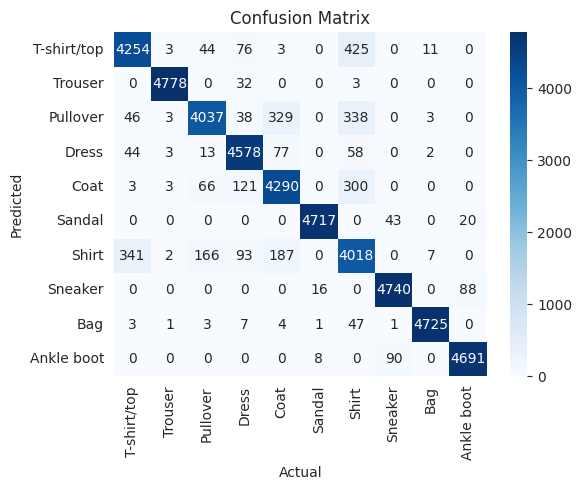

#### Validation Set #### 

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
---  Confusion Matrix  ---
                       Actual T-shirt/top  Actual Trouser  Actual Pullover  \
Predicted T-shirt/top                 988               0               14   
Predicted Trouser                       1            1163                0   
Predicted Pullover                     21               0              982   
Predicted Dress                        26               5                5   
Predicted Coat                          0               2               32   
Predicted Sandal                        0               0                0   
Predicted Shirt                       100               0               52   
Predicted Sneaker                       0               0                0   
Predicted Bag                           2               0                2   
Predicted Ankle boot                    0               0                0   

                       Actual Dress  Actual Co

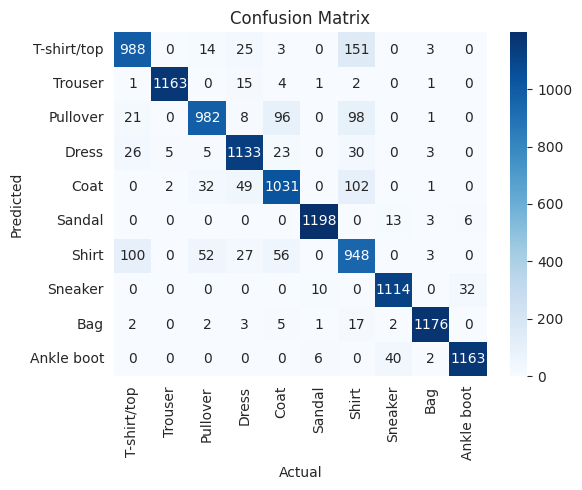

#### Test Set ####

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
---  Confusion Matrix  ---
                       Actual T-shirt/top  Actual Trouser  Actual Pullover  \
Predicted T-shirt/top                 819               0               12   
Predicted Trouser                       3             980                0   
Predicted Pullover                     12               1              804   
Predicted Dress                        15               4                7   
Predicted Coat                          0               0               27   
Predicted Sandal                        0               0                0   
Predicted Shirt                       102               0               50   
Predicted Sneaker                       0               0                0   
Predicted Bag                           3               2                2   
Predicted Ankle boot                    1               0                0   

                       Actual Dress  Actual Coat  Act

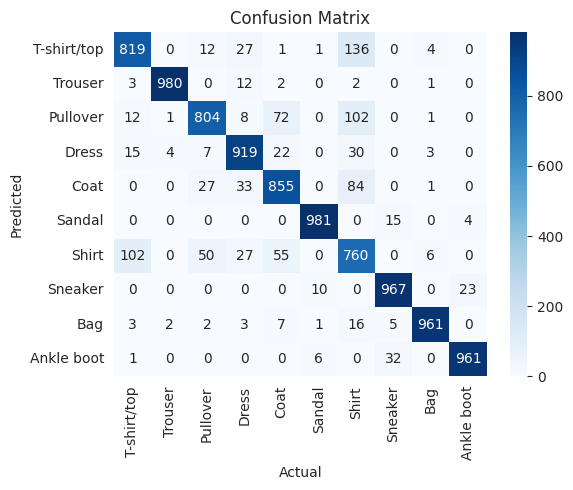

In [74]:
clf_performance(X_train, y_train,
                X_test,y_test,
                X_val, y_val,
                model,
                label_map= class_names
                )

---

### <u>Prediction</u>

* Let's take a sample from the test set and use it as if it was live data. We will consider 1 sample

(28, 28, 1)
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
This is 'Pullover'


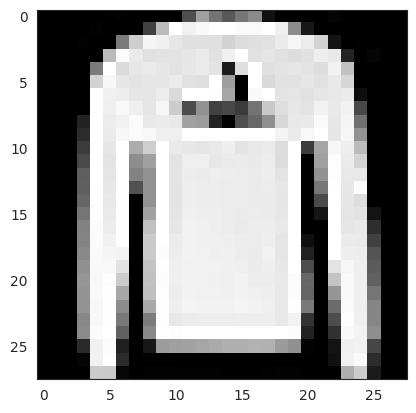

In [84]:
index = 115
my_garment = X_test[index]
class_index = np.argmax(y_test[index])
print(my_garment.shape)
print(y_test[index])
print(f"This is '{class_names[class_index]}'")

sns.set_style('white')
plt.imshow(my_garment.reshape(28,28), cmap='gray')
plt.show()

In [85]:
my_garment.shape

(28, 28, 1)

* However when interacting with the **model**, we need the data in 4 dimensions, where the first dimension is the number of images the data has, the next 2 are the image size and the last is the color channels
* In our case, we need to add the first dimension, and the value will be 1, so the final shape is (1 ,28 ,28 ,1 )
* We use the command  `np.expand_dims()` for this task

In [86]:
live_data = np.expand_dims(my_garment, axis=0)
print(live_data.shape)

(1, 28, 28, 1)


* We use `.predict()` and parse the data
* N.b. the result is a *probabilistic* result for each class.

In [87]:
prediction_proba = model.predict(live_data)
prediction_proba

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


array([[1.3537743e-02, 5.0490467e-10, 9.4785887e-01, 4.6917917e-06,
        8.6843027e-03, 3.2174925e-09, 2.9914221e-02, 4.6287719e-13,
        5.1797198e-09, 4.9420842e-11]], dtype=float32)

* So we take the index from the highest probability, which is the "winner" or predicted class

In [88]:
prediction_class = np.argmax(prediction_proba, axis=1)
prediction_class

array([2])

* Plot the probabilistic result so that you can check the predictions in a more visual fashion
* Read the pseudo-code
* In the end you are getting prediction_proba to define the associate probability for each class
* Then you plot it in a bar plot using Plotly

In [89]:
# create an empty dataframe, that will show the probability per class
# we set the probabilities as the prediction_proba
prob_per_class= pd.DataFrame(data=prediction_proba[0],
                             columns=['Probability']
                             )

# we round the values to 3 decimal points, for better visualization
prob_per_class = prob_per_class.round(3)

# we add a column to prob_per_class that shows the meaning of each class
# in this case, the species name that is mapped in the target_classes
prob_per_class['Results'] = class_names

prob_per_class

,Probability,Results
0,0.014,T-shirt/top
1,0.000,Trouser
2,0.948,Pullover
3,0.000,Dress
4,0.009,Coat
5,0.000,Sandal
6,0.030,Shirt
7,0.000,Sneaker
8,0.000,Bag
9,0.000,Ankle boot


#### Plot prediction probability for each garment in the dataset

In [90]:
fig = px.bar(
        prob_per_class,
        x = 'Results',
        y = 'Probability',
        range_y=[0,1],
        width=600, height=400,template='seaborn')
fig.update_xaxes(type='category')
fig.show()